# Ukrainian Jigsaw Dataset — Final Preprocessing

> **Goal:** Finalize the translated Ukrainian Jigsaw dataset through cleanup, validation, and preparation for model training.

At this stage, we work with the fully translated Ukrainian comments and perform the final refinement steps before training. The focus is on ensuring data quality, privacy safety, and a well-controlled class distribution suitable for robust toxicity detection.

## Key Operations
1. **Dataset Cleanup:** Removing duplicate comments, invalid or missing identifiers.
2. **Privacy-Safe Processing:** Eliminating personally identifiable information such as emails and phone numbers.
3. **Class Balancing:** Creating two dataset versions with different class ratios (1:1, 1:2).
4. **Export:** Saving the finalized dataset for downstream modeling experiments.

## Importing Dependencies

In [1]:
import warnings
import re

warnings.filterwarnings("ignore")

import pandas as pd

from toxicity_detector.data import text_cleaning as tc
from toxicity_detector.data import sampling as s
from toxicity_detector.utils.plotting import plot_category_distribution
from toxicity_detector.config.labels import LABELS_EN
from toxicity_detector.config import JIGSAW_PROCESSED

pd.set_option("display.max_colwidth", None)

## Loading Data

In [2]:
train_df = pd.read_csv(JIGSAW_PROCESSED["train"])
test_df = pd.read_csv(JIGSAW_PROCESSED["test"])
train_uk_df = pd.read_csv(JIGSAW_PROCESSED["train_uk"])
test_uk_df = pd.read_csv(JIGSAW_PROCESSED["test_uk"])

In [4]:
print(f"English Jigsaw train dataset shape: {train_df.shape}")
print(f"Ukrainian Jigsaw train dataset shape: {train_uk_df.shape}")
print(f"English Jigsaw test dataset shape: {test_df.shape}")
print(f"Ukrainian Jigsaw test dataset shape: {test_uk_df.shape}")

English Jigsaw train dataset shape: (53968, 20)
Ukrainian Jigsaw train dataset shape: (53949, 2)
English Jigsaw test dataset shape: (6000, 20)
Ukrainian Jigsaw test dataset shape: (5488, 2)


*We observe that the shapes of the original English datasets and the translated datasets differ, indicating the presence of redundant comments. Therefore, we will remove them.*

# 1.0 Dataset Cleanup

In [5]:
train_uk_df = train_uk_df[train_uk_df["id"].isin(train_df["id"])]
test_uk_df = test_uk_df[test_uk_df["id"].isin(test_df["id"])]

print(f"English Jigsaw train dataset shape: {train_df.shape}")
print(f"Ukrainian Jigsaw train dataset shape: {train_uk_df.shape}")
print(f"English Jigsaw test dataset shape: {test_df.shape}")
print(f"Ukrainian Jigsaw test dataset shape: {test_uk_df.shape}")

English Jigsaw train dataset shape: (53968, 20)
Ukrainian Jigsaw train dataset shape: (53949, 2)
English Jigsaw test dataset shape: (6000, 20)
Ukrainian Jigsaw test dataset shape: (5488, 2)


In [6]:
# Checking for duplicates within comments
train_uk_df["translated"].nunique(), test_uk_df["translated"].nunique(), train_df["comment_text"].nunique(), test_df["comment_text"].nunique()

(53949, 5488, 53968, 6000)

In [7]:
# Dropping duplicates
train_uk_df.drop_duplicates(subset=["translated"], inplace=True)
test_uk_df.drop_duplicates(subset=["translated"], inplace=True)

In [8]:
print(f"English Jigsaw train dataset shape: {train_df.shape}")
print(f"Ukrainian Jigsaw train dataset shape: {train_uk_df.shape}")
print(f"English Jigsaw test dataset shape: {test_df.shape}")
print(f"Ukrainian Jigsaw test dataset shape: {test_uk_df.shape}")

English Jigsaw train dataset shape: (53968, 20)
Ukrainian Jigsaw train dataset shape: (53949, 2)
English Jigsaw test dataset shape: (6000, 20)
Ukrainian Jigsaw test dataset shape: (5488, 2)


In [9]:
# Merging datasets by id (to include all the columns)
train_df = train_uk_df.merge(train_df, how="inner", on="id")
test_df = test_uk_df.merge(test_df, how="inner", on="id")

In [10]:
train_df.dropna(subset=["translated"], inplace=True)
test_df.dropna(subset=["translated"], inplace=True)

train_df.shape, test_df.shape

((53949, 21), (5488, 21))

# 1.1 Sensitive Data Removal

In [11]:
# We'll remove the emails and phone numbers
tags = r"\S+\[USER\]\S*\.\w+"

def clean_jigsaw_uk(text):
    text = re.sub(tags, "", text)
    text = tc.handle_urls_emails(text)
    text = tc.handle_phone_numbers(text)
    return text

In [12]:
train_df["translated"] = train_df["translated"].apply(clean_jigsaw_uk)
test_df["translated"] = test_df["translated"].apply(clean_jigsaw_uk)

train_df["comment_text"] = train_df["comment_text"].apply(clean_jigsaw_uk)
test_df["comment_text"] = test_df["comment_text"].apply(clean_jigsaw_uk)

# 2.0 Class Balancing

**Current distribution:** 
- Binary (toxic:non-toxic): 1:2

We'll prepare two dataset versions for experimentation:

1. **Imbalanced (1:2):** Initial distribution
   - Approximately reflects real-world comment patterns

2. **Binary Balanced (1:1):** Equal toxic/non-toxic samples
   - Downsamples non-toxic comments
   - Improves overall toxic detection

In [13]:
# Checking the number of toxic comments in the train and test datasets
train_df[train_df["label_count"] > 0].shape[0], test_df[test_df["label_count"] > 0].shape[0]

(18003, 1684)

In [14]:
identity_categories = ["male", "female", "homosexual_gay_or_lesbian", "christian", "jewish", "muslim", "black", "white", "psychiatric_or_mental_illness"]

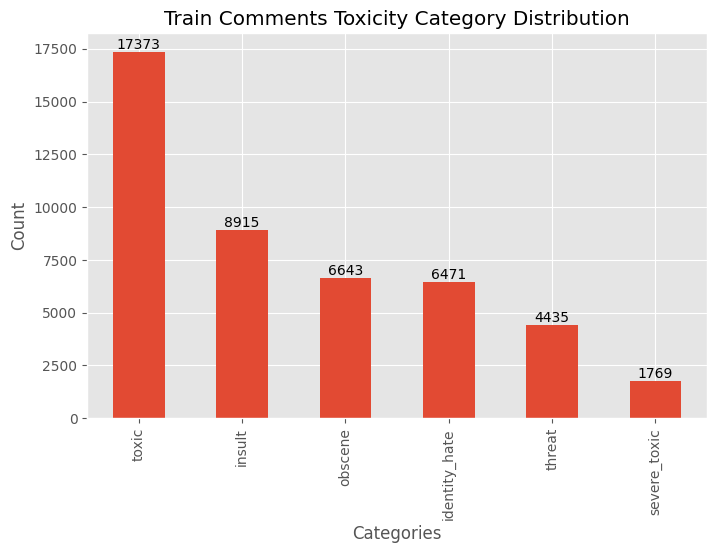

In [15]:
plot_category_distribution(train_df, LABELS_EN, title="Train Comments Toxicity Category Distribution")

In [17]:
train_binary_balanced_df = s.balance_binary_classes(train_df, "toxic", identity_categories=identity_categories, identity_fraction=0.5)
train_binary_balanced_df.shape

(33458, 21)

In [18]:
test_binary_balanced_df = s.balance_binary_classes(test_df, "toxic", identity_categories=identity_categories, identity_fraction=0.5)
test_binary_balanced_df.shape

(3211, 21)

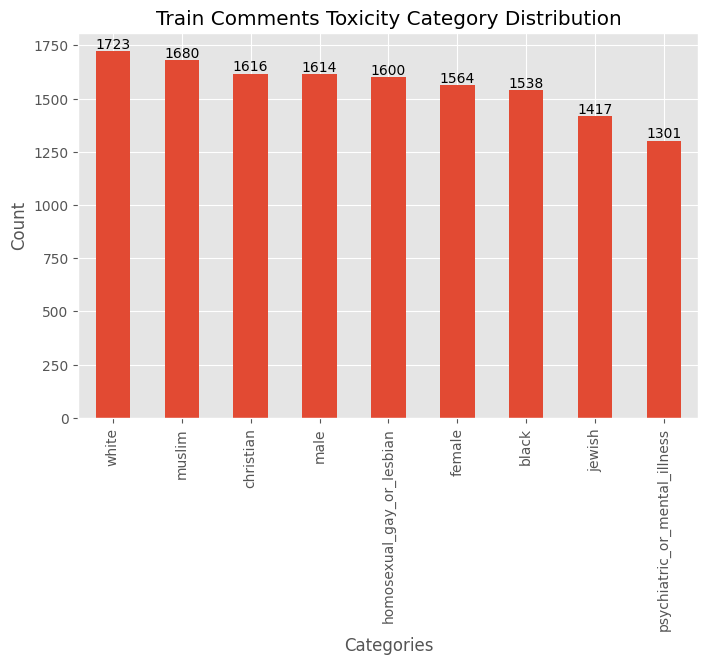

In [19]:
plot_category_distribution(train_binary_balanced_df, identity_categories, title="Train Comments Toxicity Category Distribution")

# 3.0 Data Export

In [20]:
train_df.shape, train_binary_balanced_df.shape, test_df.shape, test_binary_balanced_df.shape

((53949, 21), (33458, 21), (5488, 21), (3211, 21))

In [21]:
train_df.to_csv(JIGSAW_PROCESSED["train_uk"], index=False)
test_df.to_csv(JIGSAW_PROCESSED["test_uk"], index=False)

In [22]:
train_binary_balanced_df.to_csv(JIGSAW_PROCESSED["train_uk_bin"], index=False)
test_binary_balanced_df.to_csv(JIGSAW_PROCESSED["test_uk_bin"], index=False)